In [ ]:
# Importing important libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, math
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, SimpleRNN, GRU
import tensorflow as tf
import numpy as np
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Setting the seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# Specification
TICKER = "^NSEI" # NIFTY 50 Yahoo Finance Ticker
START_DATE = "2010-01-01"
END_DATE = None
USE_FEATURES = ['Close']
TIME_STEPS = 60 # Sequence Length
TEST_SPLIT = 0.2
VIZ_SAMPLE_DAYS = 1000 # how many recent days to show in some plots
EPOCHS = 20
BATCH_SIZE = 32

In [ ]:
# Downloading the data
print("Downloading the data for", TICKER)
df = yf.download(TICKER, START_DATE, END_DATE, progress = False)
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop = True)
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0


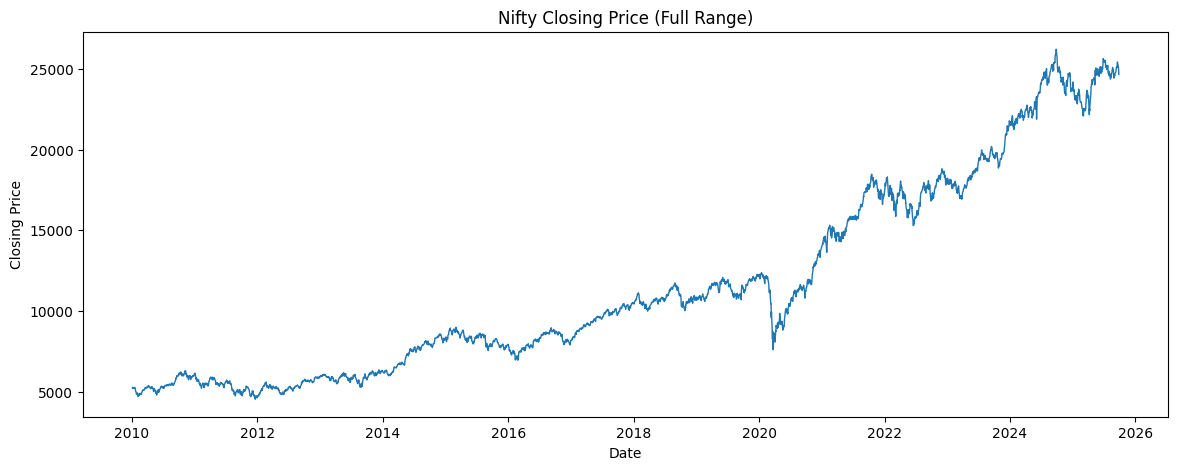

In [ ]:
# Plots
plt.figure(figsize = (14, 5))
plt.plot(df['Date'], df['Close'], lw = 1)
plt.title('Nifty Closing Price (Full Range)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

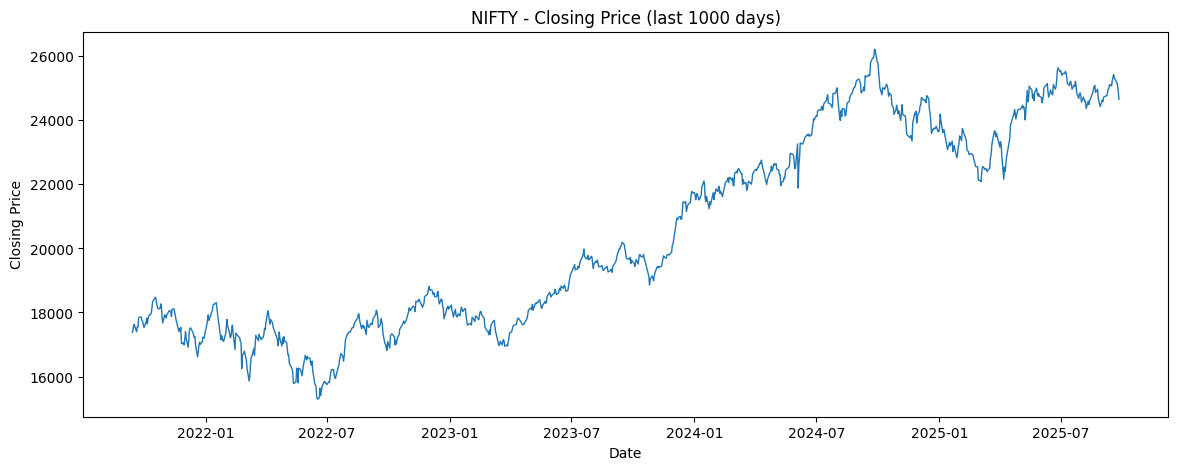

In [ ]:
# Last 1000 rows in the data
plt.figure(figsize = (14, 5))
plt.plot(df['Date'].iloc[-VIZ_SAMPLE_DAYS:], df['Close'].iloc[-VIZ_SAMPLE_DAYS:], lw = 1)
plt.title(f"NIFTY - Closing Price (last {VIZ_SAMPLE_DAYS} days)")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

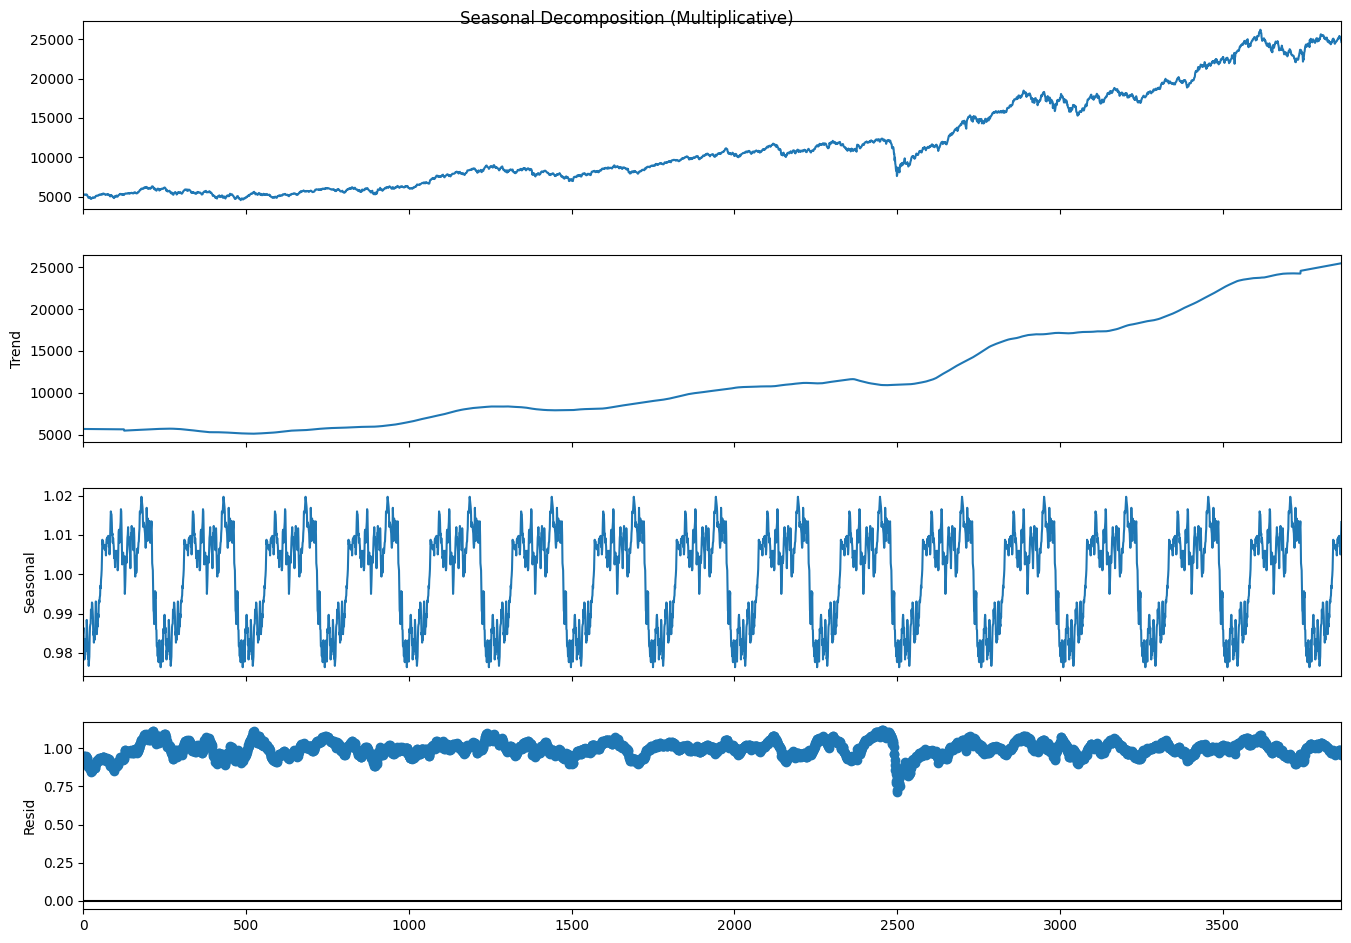

In [ ]:
# Decomposition
try:
  decom_period = 252
  decomposed = seasonal_decompose(df['Close'], model = 'multiplicative',
                                  period = decom_period, extrapolate_trend = 'freq')
  fig = decomposed.plot()
  fig.set_size_inches(15, 10)
  plt.suptitle('Seasonal Decomposition (Multiplicative)')
  plt.show()
except Exception as e:
  print('Seasonal Decomposition skipped {reason} :', e)

In [ ]:
# Preprocessing
features = USE_FEATURES.copy()
data = df[features].astype('float32').values
print('Using Features :', features)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

Using Features : ['Close']


In [ ]:
'''
Interview Question -> Why are we scaling the data ?
Answer -> Gradient Stability, Faster Connversion
'''

In [ ]:
# Created sequences for supervised learning
def create_sequences_multivariate(data_array, time_steps):
  X, y = [], []
  for i in range(time_steps, len(data_array)):
    X.append(data_array[i - time_steps : i])
    y.append(data_array[i])
  X = np.array(X)
  y = np.array(y)
  return X, y

In [ ]:
# Driver Code
X, y = create_sequences_multivariate(data_scaled, TIME_STEPS)
print('X shape :', X.shape)
print('y shape :', y.shape)

X shape : (3805, 60, 1)
y shape : (3805, 1)


In [ ]:
# Train Test Split
split = int(X.shape[0] * (1 - TEST_SPLIT))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [ ]:
'''
Interview Question -> Why do we avoid train_test_split() function in RNN to split the data ?
Answer -> We want to maintain the sequence of the data.
'''

In [ ]:
# Model Builders
n_features = X.shape[-1]
early_stop = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True)

In [ ]:
# Function for RNN
def build_rnn(units_list = [64], dropout = 0.2, input_shape = (TIME_STEPS, n_features)):
  model = Sequential()
  for i, units in enumerate(units_list):
    return_seq = (i < len(units_list) - 1)
    if i == 0:
      model.add(SimpleRNN(units, return_sequences = return_seq, input_shape = input_shape))
    else:
      model.add(SimpleRNN(units, return_sequences = return_seq))
    model.add(Dropout(dropout))
    model.add(Dense(n_features))
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])
  return model

In [ ]:
# Function for LSTM
def build_lstm(units_list = [64], dropout = 0.2, input_shape = (TIME_STEPS, n_features)):
  model = Sequential()
  for i, units in enumerate(units_list):
    return_seq = (i < len(units_list) - 1)
    if i == 0:
      model.add(LSTM(units, return_sequences = return_seq, input_shape = input_shape))
    else:
      model.add(LSTM(units, return_sequences = return_seq))
    model.add(Dropout(dropout))
    model.add(Dense(n_features))
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])
  return model

In [ ]:
# Function for GRU
def build_gru(units_list = [64], dropout = 0.2, input_shape = (TIME_STEPS, n_features)):
  model = Sequential()
  for i, units in enumerate(units_list):
    return_seq = (i < len(units_list) - 1)
    if i == 0:
      model.add(GRU(units, return_sequences = return_seq, input_shape = input_shape))
    else:
      model.add(GRU(units, return_sequences = return_seq))
    model.add(Dropout(dropout))
    model.add(Dense(n_features))
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])
  return model

In [ ]:
# Define Model Variants
configs = [
    ("RNN-32", build_rnn(units_list = [32], dropout = 0.1)),
    ("RNN-64-32", build_rnn(units_list = [64, 32], dropout = 0.2)),
    ("RNN-128-64-32", build_rnn(units_list = [128, 64, 32], dropout = 0.3)),
    ("LSTM-32", build_lstm(units_list = [32], dropout = 0.1)),
    ("LSTM-64-32", build_lstm(units_list = [64, 32], dropout = 0.2)),
    ("LSTM-128-64-32", build_lstm(units_list = [128, 64, 32], dropout = 0.3)),
    ("GRU-32", build_gru(units_list = [32], dropout = 0.1)),
    ("GRU-64-32", build_gru(units_list = [64, 32], dropout = 0.2)),
    ("GRU-128-64-32", build_gru(units_list = [128, 64, 32], dropout = 0.3)),
]

In [ ]:
# Training all the variants and recording metrics and runtime
history = {}
results = {}
timings = {}
predictions = {}

for name, model in configs:
  print("\n============================================================================")
  print('Training Model :', name)
  print('\n', model.summary())
  start = time.time()
  h =  model.fit(
      X_train, y_train,
      epochs = EPOCHS,
      batch_size = BATCH_SIZE,
      validation_split = 0.15,
      callbacks = [early_stop],
      verbose = 1
  )
  elapsed = time.time() - start

  # Predict and rescale the target
  y_pred_scaled = model.predict(X_test)
  y_pred_rescaled = scaler.inverse_transform(y_pred_scaled)
  y_test_rescaled = scaler.inverse_transform(y_test)

  # Evaluate the model
  close_idx = features.index('Close')
  rmse = math.sqrt(mean_squared_error(y_test_rescaled[:, close_idx], y_pred_rescaled[:, close_idx]))
  mae = np.mean(np.abs(y_pred_rescaled[:, close_idx] - y_test_rescaled[:, close_idx]))

  print(f"{name} RMSE (Close) : {rmse:.3f}, MAE (Close) : {mae:.3f}, Time : {elapsed:.1f}s")
  history[name] = h.history
  results[name] = [rmse, mae]
  timings[name] = elapsed
  predictions[name] = {"y_true" : y_test_rescaled[:, close_idx], "y_pred" : y_pred_rescaled[:, close_idx]}


Training Model : RNN-32


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 60, 128)        │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 60, 1)          │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 60, 1)          │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,755 (260.76 KB)

 Trainable params: 66,755 (260.76 KB)

 Non-trainable params: 0 (0.00 B)


 None
Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - loss: 0.0140 - mae: 0.0907 - val_loss: 3.7353e-04 - val_mae: 0.0156
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 228ms/step - loss: 0.0010 - mae: 0.0231 - val_loss: 0.0025 - val_mae: 0.0463
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 208ms/step - loss: 8.4119e-04 - mae: 0.0211 - val_loss: 3.0624e-04 - val_mae: 0.0142
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 267ms/step - loss: 6.8617e-04 - mae: 0.0195 - val_loss: 9.5044e-04 - val_mae: 0.0276
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 201ms/step - loss: 5.8297e-04 - mae: 0.0176 - val_loss: 9.9072e-04 - val_mae: 0.0282
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - loss: 6.2518e-04 - mae: 0.0184 - val_loss: 0.0010 - val_mae: 0.0292
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
GRU-128-64-32 RMSE (Close) : 805.412, MAE (Close) : 673.367, Time : 128.9s


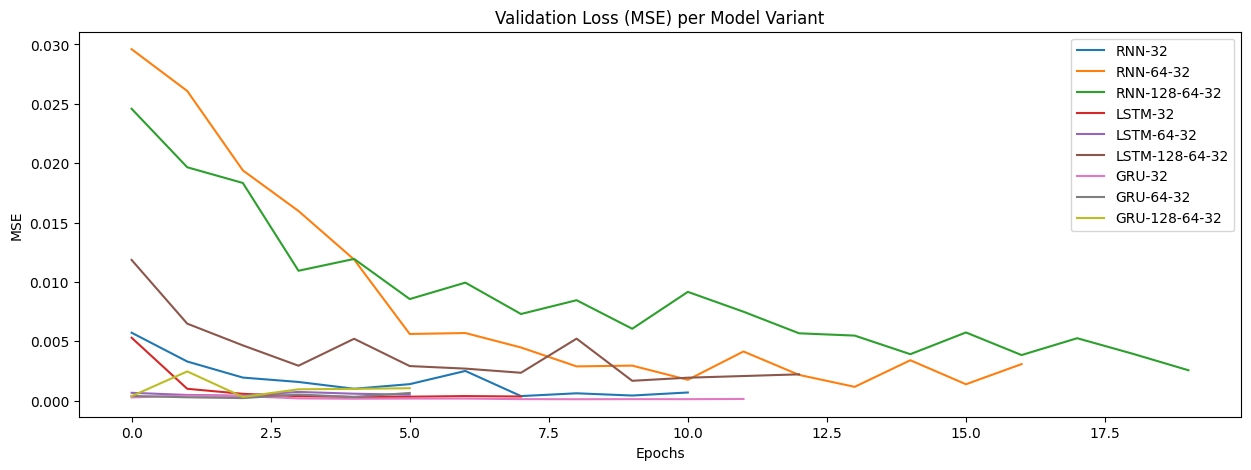

In [ ]:
# Visual Comparison
plt.figure(figsize = (15, 5))
for name, h in history.items():
  if "val_loss" in h:
    plt.plot(h['val_loss'], label = name)
plt.title("Validation Loss (MSE) per Model Variant")
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

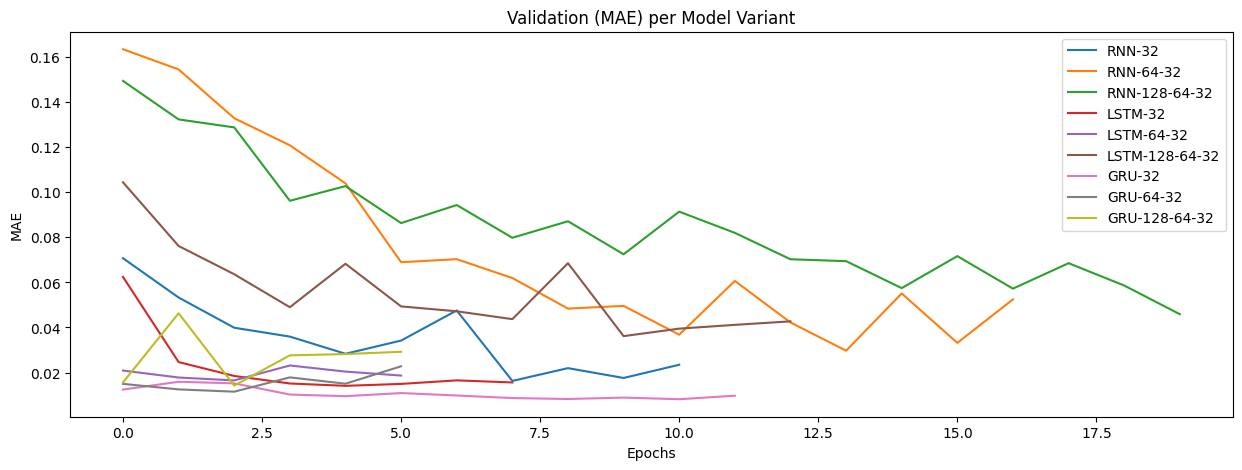

In [ ]:
# Visual Comparison
plt.figure(figsize = (15, 5))
for name, h in history.items():
  if "val_mae" in h:
    plt.plot(h['val_mae'], label = name)
plt.title("Validation (MAE) per Model Variant")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [ ]:
# Getting the best model
best_name = min(results.keys(), key = lambda k : results[k][0])
print('Best Model by RMSE (Close):', best_name, results[best_name])

y_true = predictions[best_name]['y_true']
y_pred = predictions[best_name]['y_pred']

Best Model by RMSE (Close): GRU-32 [245.64188078125034, np.float32(190.05495)]


<function matplotlib.pyplot.show(close=None, block=None)>

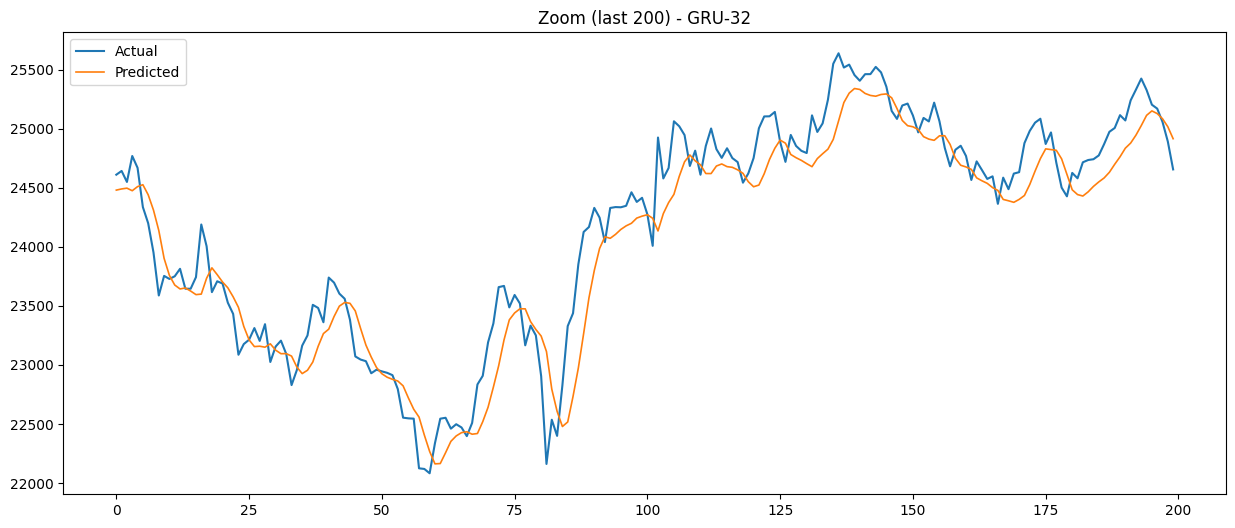

In [ ]:
# Zoom into the last 200 test points
zoom_n = min(200, len(y_true))
plt.figure(figsize = (15, 6))
plt.plot(y_true[-zoom_n:], label = 'Actual', lw = 1.5)
plt.plot(y_pred[-zoom_n:], label = 'Predicted', lw = 1.2)
plt.title(f"Zoom (last {zoom_n}) - {best_name}")
plt.legend()
plt.show